FADE Lizandre - MERIAUX Hugo

SIG3 - SLIT et séquences audio

In [1]:
locals().clear()
from numpy import abs,linspace,sin,pi,exp,arange,log10,concatenate,angle
from scipy.signal import freqz
from matplotlib.pyplot import plot,close
import matplotlib.pyplot as plt
close('all')

In [2]:
fa=1053
fe=4000
duree=0.5
sig=linspace(0,duree,int(duree*fe))
sig=sin(2*pi*fa*sig)

In [3]:
def dft(seq):
    Seq=[]
    s=0
    for j in range(1,600): #1100/duree <-> fmax
        s=0
        for i in range(len(seq)):
            s= s+exp(-1j*2*pi*i*j/len(seq))*seq[i]
        Seq.append(abs(s))
    return Seq #//pk nu? Absolument pas utile??

DFT_sig=dft(sig)

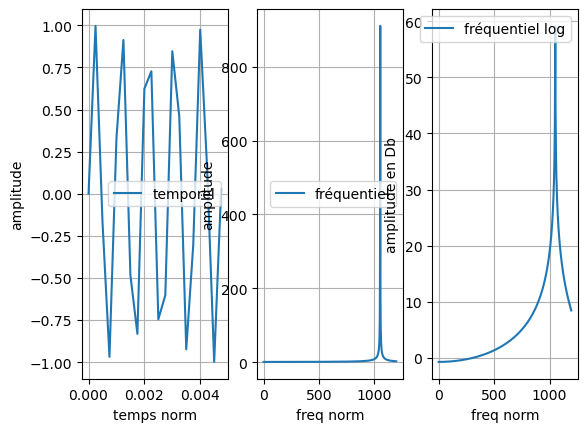

In [4]:
fig, ax = plt.subplots(1,3)
ax[0].plot(arange(0,len(sig))[:20]*duree/len(sig),sig[:20],label='temporel')
ax[0].set_xlabel('temps norm')
ax[0].set_ylabel('amplitude')
ax[0].grid()
ax[0].legend()
DFT_sig=dft(sig)
#un TFD classique suppose que la durée est de 1s, il faut mult DFT_sig par 1/duree ici 2
ax[1].plot(arange(0,len(DFT_sig)*2,2),DFT_sig,label='fréquentiel')
ax[1].set_xlabel('freq norm')
ax[1].set_ylabel('amplitude')
ax[1].grid()
ax[1].legend()
#Echelle dB
DFT_sig_log=[20*log10(i) for i in DFT_sig]
ax[2].plot(arange(0,len(DFT_sig)*2,2),DFT_sig_log,label='fréquentiel log')
ax[2].set_xlabel('freq norm')
ax[2].set_ylabel('amplitude en Db')
ax[2].grid()
ax[2].legend()

plt.show()

[ 0.          0.99646739 -2.16030266 ...  2.09935842  0.36284708
 -2.16030266]


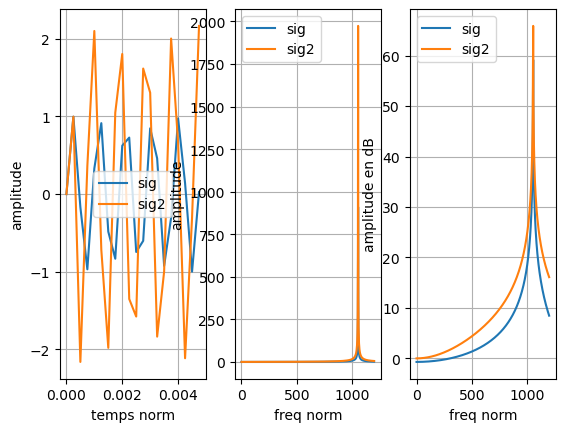

In [5]:
#On considère que sig =0 pour temps<0

sig2_1=[sig[0],sig[1]-sig[0]]
sig2_2=[sig[i]-2*sig[i-1]+sig[i-2] for i in range(2,len(sig))]
sig2=concatenate((sig2_1,sig2_2))
print(sig2)
DFT_sig2=dft(sig2)
#On superpose désormais sig et sig2
fig, ax = plt.subplots(1,3)
ax[0].plot(arange(0,len(sig))[:20]*duree/len(sig),sig[:20],label='sig')
ax[0].plot(arange(0,len(sig2))[:20]*duree/len(sig2),sig2[:20],label='sig2')
ax[0].set_xlabel('temps norm')
ax[0].set_ylabel('amplitude')
ax[0].grid()
ax[0].legend()
DFT_sig=dft(sig)
#un TFD classique suppose que la durée est de 1s, il faut mult DFT_sig par 1/duree ici 2
ax[1].plot(arange(0,len(DFT_sig)*2,2),DFT_sig,label='sig')
ax[1].plot(arange(0,len(DFT_sig2)*2,2),DFT_sig2,label='sig2')
ax[1].set_xlabel('freq norm')
ax[1].set_ylabel('amplitude')
ax[1].grid()
ax[1].legend()
#Echelle dB
DFT_sig_log=[20*log10(i) for i in DFT_sig]
DFT_sig2_log=[20*log10(i) for i in DFT_sig2]
ax[2].plot(arange(0,len(DFT_sig)*2,2),DFT_sig_log,label='sig')
ax[2].plot(arange(0,len(DFT_sig2)*2,2),DFT_sig2_log,label='sig2')
ax[2].set_xlabel('freq norm')
ax[2].set_ylabel('amplitude en dB')
ax[2].grid()
ax[2].legend()

plt.show()

In [6]:
#La réponse impulsionnelle est : //pk? les??
h=[1,-2,1]
#La réponse en fréquence du filtre :
Lsig_f=[sin(2*pi*i*sig) for i in range(2000)] #c'est en fait une liste de sig2 dont le fa a été modifié !
H=[[Lsig_f[i][0],Lsig_f[i][1]-2*Lsig_f[i][0]]+[Lsig_f[i][j]-2*Lsig_f[i][j-1]+Lsig_f[i][j-2] for j in range(2,len(sig))] for i in range(2000)]
#Pareil : pour t<0, sig est nul

[ 0.          0.99646739 -2.16030266 ...  2.09935842  0.36284708
 -2.16030266]


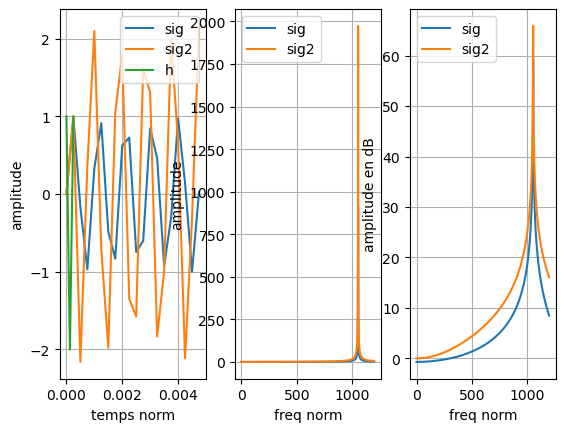

In [7]:
#On considère que sig =0 pour temps<0

sig2_1=[sig[0],sig[1]-sig[0]]
sig2_2=[sig[i]-2*sig[i-1]+sig[i-2] for i in range(2,len(sig))]
sig2=concatenate((sig2_1,sig2_2))
print(sig2)
DFT_sig2=dft(sig2)
#On superpose désormais sig et sig2
fig, ax = plt.subplots(1,3)
ax[0].plot(arange(0,len(sig))[:20]*duree/len(sig),sig[:20],label='sig')
ax[0].plot(arange(0,len(sig2))[:20]*duree/len(sig2),sig2[:20],label='sig2')
ax[0].plot(arange(0,len(h))*duree/fe,h,label='h')
ax[0].set_xlabel('temps norm')
ax[0].set_ylabel('amplitude')
ax[0].grid()
ax[0].legend()
DFT_sig=dft(sig)
#un TFD classique suppose que la durée est de 1s, il faut mult DFT_sig par 1/duree ici 2
ax[1].plot(arange(0,len(DFT_sig)*2,2),DFT_sig,label='sig')
ax[1].plot(arange(0,len(DFT_sig2)*2,2),DFT_sig2,label='sig2')
#ax[1].plot(arange(0,len(H)*2,2),abs(H),label='abs_H')    //Aimerais bien savoir comment faire
ax[1].set_xlabel('freq norm')
ax[1].set_ylabel('amplitude')
ax[1].grid()
ax[1].legend()
#Echelle dB
DFT_sig_log=[20*log10(i) for i in DFT_sig]
DFT_sig2_log=[20*log10(i) for i in DFT_sig2]
ax[2].plot(arange(0,len(DFT_sig)*2,2),DFT_sig_log,label='sig')
ax[2].plot(arange(0,len(DFT_sig2)*2,2),DFT_sig2_log,label='sig2')
#ax[2].plot(arange(0,len(H[1053])*2,2),angle(H[1053]),label='angle_H')
ax[2].set_xlabel('freq norm')
ax[2].set_ylabel('amplitude en dB')
ax[2].grid()
ax[2].legend()

plt.show()

A corr, faire dft direct sur h

III - A la découverte d'une séquence audio

In [108]:
import soundfile
import sounddevice
audio, samplerate = soundfile.read('jazz5.wav') #Goldeneye.wav
samplerate2=samplerate
sounddevice.play(audio,samplerate2)
sounddevice.wait()
#Convention en 0 ?

In [19]:
print("Dimension de l'audio : "+str(len(audio)))
print("Dimension de samplerate : 1 (scalaire)")

Dimension de l'audio : 317952
Dimension de samplerate : 1 (scalaire)


In [20]:
def dft(seq):
    Seq=[]
    s=0
    for j in range(1,1000): #1100/duree <-> fmax
        s=0
        for i in range(len(seq)):
            s= s+exp(-1j*2*pi*i*j/len(seq))*seq[i]
        Seq.append(abs(s))
    return Seq #//pk nu? Absolument pas utile??


7.209795918367347


C:\Users\nicol\AppData\Local\Temp\ipykernel_22808\1457025680.py:17: RuntimeWarning: divide by zero encountered in log10
  DFT_audio_log=[20*log10(i) for i in DFT_audio]
C:\Users\nicol\AppData\Local\Temp\ipykernel_22808\1457025680.py:17: RuntimeWarning: invalid value encountered in multiply
  DFT_audio_log=[20*log10(i) for i in DFT_audio]


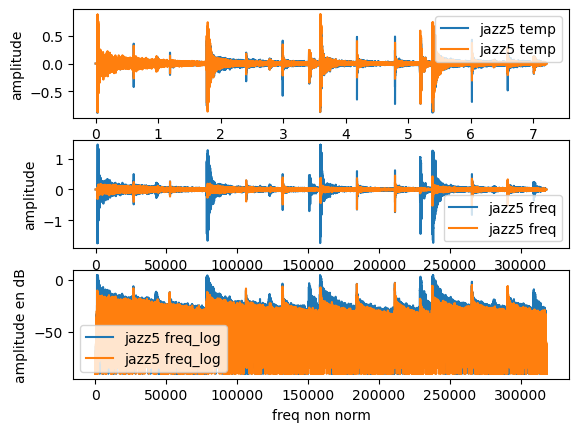

In [57]:
import numpy as np
fig, ax = plt.subplots(3,1)

print(len(audio)/samplerate)

ax[0].plot(arange(0,len(audio))/samplerate,audio,label='jazz5 temp')
ax[0].set_xlabel("temps norm")
ax[0].set_ylabel("amplitude")
ax[0].legend()
DFT_audio=np.fft.fft(audio)
#utiliser int ici crée une imprécision mais tant pis
#j'enlève les 20 premières valeurs
ax[1].plot(arange(0,len(DFT_audio)),DFT_audio,label='jazz5 freq')
ax[1].set_xlabel("freq non norm")
ax[1].set_ylabel("amplitude")
ax[1].legend()
DFT_audio_log=[20*log10(i) for i in DFT_audio]
ech_log =arange(0,len(DFT_audio_log))
ax[2].plot(ech_log,DFT_audio_log,label='jazz5 freq_log')
ax[2].set_xlabel("freq non norm")
ax[2].set_ylabel("amplitude en dB")
ax[2].legend()

plt.show()
    

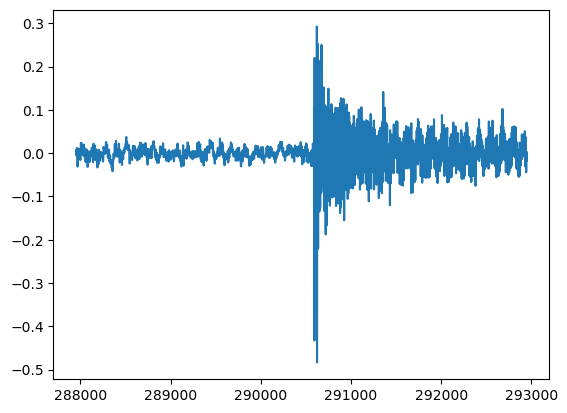

In [64]:
Nobs = audio[len(audio)-30000:len(audio)-25000]
nobs=len(Nobs)
Nobs_x=arange(len(audio)-30000,len(audio)-25000)

Nobs=[Nobs[i][0] for i in range(len(Nobs))]
#On s'intéresse qu'à une sortie
plt.plot(Nobs_x,Nobs)

plt.show()


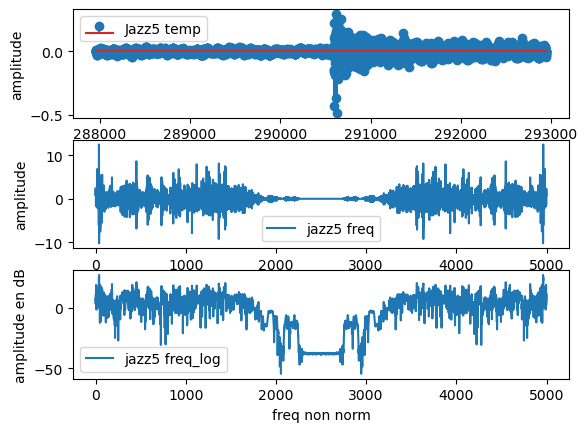

In [61]:
import numpy as np
fig, ax = plt.subplots(3,1)

ax[0].stem(Nobs_x,Nobs,label='Jazz5 temp')
ax[0].set_xlabel("temps non norm")
ax[0].set_ylabel("amplitude")
ax[0].legend()
DFT_Nobs=np.fft.fft(Nobs)
#utiliser int ici crée une imprécision mais tant pis
#j'enlève les 20 premières valeurs
ax[1].plot(arange(0,len(DFT_Nobs)),DFT_Nobs,label='jazz5 freq')
ax[1].set_xlabel("freq non norm")
ax[1].set_ylabel("amplitude")
ax[1].legend()
DFT_Nobs_log=[20*log10(i) for i in DFT_Nobs]
ech_log =arange(0,len(DFT_Nobs_log))
ax[2].plot(ech_log,DFT_Nobs_log,label='jazz5 freq_log')
ax[2].set_xlabel("freq non norm")
ax[2].set_ylabel("amplitude en dB")
ax[2].legend()

plt.show()

III-Filtr num : le retard

[0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]


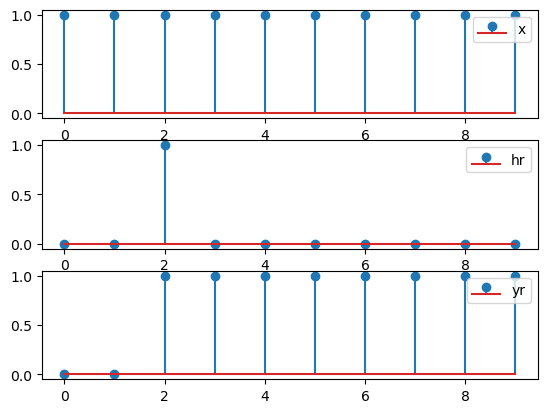

In [90]:
n=10
nr=3
absc=np.arange(0,n)
x=[1 for i in range(n)]
hr=[0 for i in range(nr-1)]+[1]+[0 for i in range(n-nr)]
yr=np.convolve(x,hr)
print(yr)
fig, ax = plt.subplots(3,1)

ax[0].stem(absc,x,label='x')
ax[1].stem(absc,hr,label='hr')
ax[2].stem(absc,yr[:n],label='yr')
ax[0].legend()
ax[1].legend()
ax[2].legend()

plt.show()

[0. 0. 0. ... 0. 0. 0.]


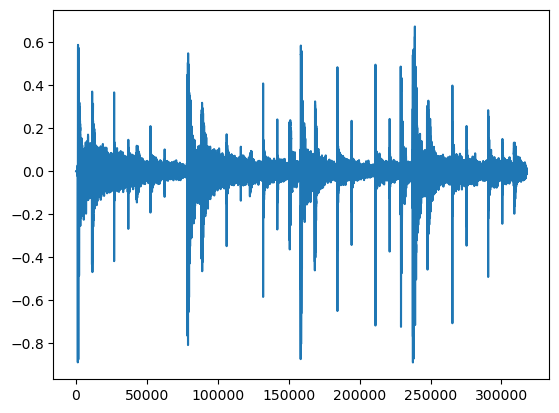

In [103]:
n0=10000
n=len(audio)
hr=[0 for i in range(n0-1)]+[1/2]+[0 for i in range(n-n0)]
absc=np.arange(0,n)
audio1=[audio[i][0] for i in range(n)]
yr=np.convolve(audio1,hr)
print(yr)

plt.plot(arange(0,n),audio1+np.array(yr[:n]))
plt.show()

In [109]:
sounddevice.play(audio1+np.array(yr[:n]),samplerate)